In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv(
    "../data/cleaned/datapulse_sales_cleaned.csv"
)

df["order_date"] = pd.to_datetime(df["order_date"])

df.head()

,order_id,order_date,customer_id,product,category,region,quantity,unit_price,discount,payment_method,returned,gross_sales,discount_amount,net_sales,year,month,month_name,day_name
0,O00001,2025-01-01 00:00:00.000000000,C0017,Headphones,Accessories,North,3,2500,0.00,Credit Card,No,7500,0.0,7500.0,2025,1,January,Wednesday
1,O00002,2025-01-01 02:36:59.483896779,C0056,Monitor,Electronics,East,4,15000,0.00,Credit Card,No,60000,0.0,60000.0,2025,1,January,Wednesday
2,O00003,2025-01-01 05:13:58.967793558,C0182,Laptop,Electronics,North,2,65000,0.05,Cash,No,130000,6500.0,123500.0,2025,1,January,Wednesday
3,O00004,2025-01-01 07:50:58.451690338,C0144,Laptop,Electronics,East,3,65000,0.10,Debit Card,No,195000,19500.0,175500.0,2025,1,January,Wednesday
4,O00005,2025-01-01 10:27:57.935587117,C0319,Laptop,Electronics,West,1,65000,0.00,Debit Card,No,65000,0.0,65000.0,2025,1,January,Wednesday


In [7]:
df.columns

Index(['order_id', 'order_date', 'customer_id', 'product', 'category',
       'region', 'quantity', 'unit_price', 'discount', 'payment_method',
       'returned', 'gross_sales', 'discount_amount', 'net_sales', 'year',
       'month', 'month_name', 'day_name'],
      dtype='object')

In [8]:
calculated_net_sales = (
    df["gross_sales"]
    - df["discount_amount"]
)

In [9]:
# Basic DataPulse Order KPIs
total_orders = df["order_id"].nunique()

total_customers = df["customer_id"].nunique()

total_revenue = df["net_sales"].sum()

total_gross_sales = df["gross_sales"].sum()

total_discount = df["discount_amount"].sum()

total_units = df["quantity"].sum()

In [10]:
print("========== DATAPULSE ORDER KPIs ==========")

print(f"Total Orders: {total_orders:,}")
print(f"Total Customers: {total_customers:,}")
print(f"Total Units Sold: {total_units:,}")
print(f"Gross Sales: ₹{total_gross_sales:,.2f}")
print(f"Total Discounts: ₹{total_discount:,.2f}")
print(f"Net Sales: ₹{total_revenue:,.2f}")

========== DATAPULSE ORDER KPIs ==========
Total Orders: 5,000
Total Customers: 500
Total Units Sold: 14,951
Gross Sales: ₹301,411,700.00
Total Discounts: ₹22,317,400.00
Net Sales: ₹279,094,300.00


In [11]:
# Revenue associated with returned orders
returned_revenue = (
    df.loc[
        df["returned"] == "Yes",
        "net_sales"
    ].sum()
)

In [12]:
returned_revenue_pct = (
    returned_revenue
    / total_revenue
    * 100
)

In [13]:
print(
    f"Revenue Associated With Returned Transactions: "
    f"₹{returned_revenue:,.2f}"
)

print(
    "Share of Net Sales:",
    round(returned_revenue_pct, 2),
    "%"
)

Revenue Associated With Returned Transactions: ₹22,104,150.00
Share of Net Sales: 7.92 %


In [15]:
# Product Return Analysis
product_returns = (
    df.groupby("product")
      .agg(
          Orders=("order_id", "nunique"),
          Returned_Orders=(
              "returned",
              lambda x: (x == "Yes").sum()
          ),
          Revenue=("net_sales", "sum")
      )
)

In [16]:
product_returns["Return_Rate"] = (
    product_returns["Returned_Orders"]
    / product_returns["Orders"]
    * 100
)

In [17]:
product_returns["Return_Rate"] = (
    product_returns["Return_Rate"]
    .round(2)
)

In [18]:
product_returns.sort_values(
    "Return_Rate",
    ascending=False
)

,Orders,Returned_Orders,Revenue,Return_Rate
product,,,,
Webcam,616,58,6120625.0,9.42
Smartphone,649,50,71852000.0,7.70
Mouse,598,46,1307200.0,7.69
Laptop,639,49,115261250.0,7.67
Headphones,633,48,4321375.0,7.58
Tablet,602,45,50097000.0,7.48
Keyboard,612,43,3398100.0,7.03
Monitor,651,45,26736750.0,6.91


In [19]:
# Highest Return-Rate Product
highest_return_product = (
    product_returns["Return_Rate"]
    .idxmax()
)

highest_return_rate = (
    product_returns["Return_Rate"]
    .max()
)

print(
    "Highest Return-Rate Product:",
    highest_return_product
)

print(
    "Return Rate:",
    round(highest_return_rate, 2),
    "%"
)

Highest Return-Rate Product: Webcam
Return Rate: 9.42 %


In [20]:
# Lowest Return-Rate Product
lowest_return_product = (
    product_returns["Return_Rate"]
    .idxmin()
)

lowest_return_rate = (
    product_returns["Return_Rate"]
    .min()
)

print(
    "Lowest Return-Rate Product:",
    lowest_return_product
)

print(
    "Return Rate:",
    round(lowest_return_rate, 2),
    "%"
)

Lowest Return-Rate Product: Monitor
Return Rate: 6.91 %


In [21]:
# Regional Return Analysis
region_returns = (
    df.groupby("region")
      .agg(
          Orders=("order_id", "nunique"),
          Returned_Orders=(
              "returned",
              lambda x: (x == "Yes").sum()
          ),
          Revenue=("net_sales", "sum")
      )
)

In [22]:
region_returns["Return_Rate"] = (
    region_returns["Returned_Orders"]
    / region_returns["Orders"]
    * 100
)

In [23]:
region_returns["Return_Rate"] = (
    region_returns["Return_Rate"]
    .round(2)
)

In [24]:
region_returns

,Orders,Returned_Orders,Revenue,Return_Rate
region,,,,
East,1265,83,72130300.0,6.56
North,1234,100,67614895.0,8.10
South,1274,107,69978440.0,8.40
West,1227,94,69370665.0,7.66


In [25]:
# Best and Worst Region by Return Rate
highest_return_region = (
    region_returns["Return_Rate"]
    .idxmax()
)

highest_region_rate = (
    region_returns["Return_Rate"]
    .max()
)

lowest_return_region = (
    region_returns["Return_Rate"]
    .idxmin()
)

lowest_region_rate = (
    region_returns["Return_Rate"]
    .min()
)

In [26]:
print(
    "Highest Return-Rate Region:",
    highest_return_region,
    f"({highest_region_rate:.2f}%)"
)

print(
    "Lowest Return-Rate Region:",
    lowest_return_region,
    f"({lowest_region_rate:.2f}%)"
)

Highest Return-Rate Region: South (8.40%)
Lowest Return-Rate Region: East (6.56%)


In [28]:
# Discount Analysis
discount_analysis = (
    df.groupby("product")
      .agg(
          Average_Discount=("discount", "mean"),
          Total_Discount=("discount_amount", "sum"),
          Gross_Sales=("gross_sales", "sum"),
          Net_Sales=("net_sales", "sum"),
          Orders=("order_id", "nunique")
      )
      .sort_values(
          "Average_Discount",
          ascending=False
      )
)

In [29]:
discount_analysis.round(2)

,Average_Discount,Total_Discount,Gross_Sales,Net_Sales,Orders
product,,,,,
Headphones,0.08,361125.0,4682500,4321375.0,633
Smartphone,0.08,5908000.0,77760000,71852000.0,649
Webcam,0.08,508375.0,6629000,6120625.0,616
Laptop,0.08,9343750.0,124605000,115261250.0,639
Mouse,0.08,108000.0,1415200,1307200.0,598
Keyboard,0.07,271900.0,3670000,3398100.0,612
Monitor,0.07,2183250.0,28920000,26736750.0,651
Tablet,0.07,3633000.0,53730000,50097000.0,602


In [31]:
# Highest Discount Product
highest_discount_product = (
    discount_analysis["Average_Discount"]
    .idxmax()
)

highest_discount = (
    discount_analysis["Average_Discount"]
    .max()
)

print(
    "Highest Average Discount Product:",
    highest_discount_product
)

print(
    "Average Discount:",
    round(highest_discount, 2),
    "%"
)

Highest Average Discount Product: Headphones
Average Discount: 0.08 %


In [32]:
# Overall Discount Impact
discount_rate_overall = (
    total_discount
    / total_gross_sales
    * 100
)

In [33]:
print(
    "Overall Discount Rate:",
    round(discount_rate_overall, 2),
    "%"
)

Overall Discount Rate: 7.4 %


In [34]:
# Discount vs Return
discount_return = (
    df.groupby("returned")
      .agg(
          Orders=("order_id", "nunique"),
          Average_Discount=("discount", "mean"),
          Average_Discount_Amount=("discount_amount", "mean"),
          Average_Net_Sales=("net_sales", "mean")
      )
)

In [35]:
discount_return.round(2)

,Orders,Average_Discount,Average_Discount_Amount,Average_Net_Sales
returned,,,,
No,4616,0.08,4494.75,55673.78
Yes,384,0.07,4087.63,57562.89


In [36]:
# Calculate the discount difference
returned_discount = (
    discount_return.loc[
        "Yes",
        "Average_Discount"
    ]
)

non_returned_discount = (
    discount_return.loc[
        "No",
        "Average_Discount"
    ]
)

discount_difference = (
    returned_discount
    - non_returned_discount
)

In [37]:
print(
    "Average Discount — Returned Orders:",
    round(returned_discount, 2),
    "%"
)

print(
    "Average Discount — Non-Returned Orders:",
    round(non_returned_discount, 2),
    "%"
)

print(
    "Difference:",
    round(discount_difference, 2),
    "percentage points"
)

Average Discount — Returned Orders: 0.07 %
Average Discount — Non-Returned Orders: 0.08 %
Difference: -0.01 percentage points


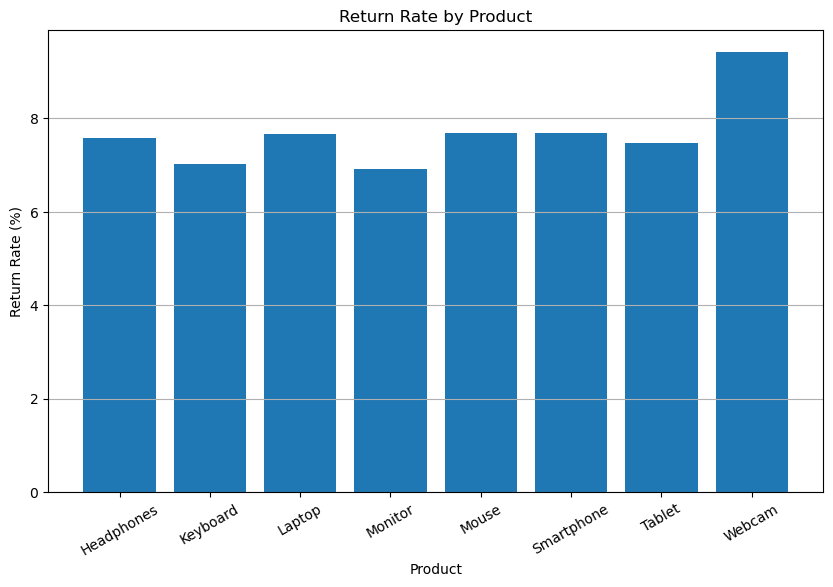

In [38]:
# Return Rate by Product
plt.figure(figsize=(10, 6))

plt.bar(
    product_returns.index,
    product_returns["Return_Rate"]
)

plt.title("Return Rate by Product")
plt.xlabel("Product")
plt.ylabel("Return Rate (%)")

plt.xticks(rotation=30)
plt.grid(axis="y")

plt.show()

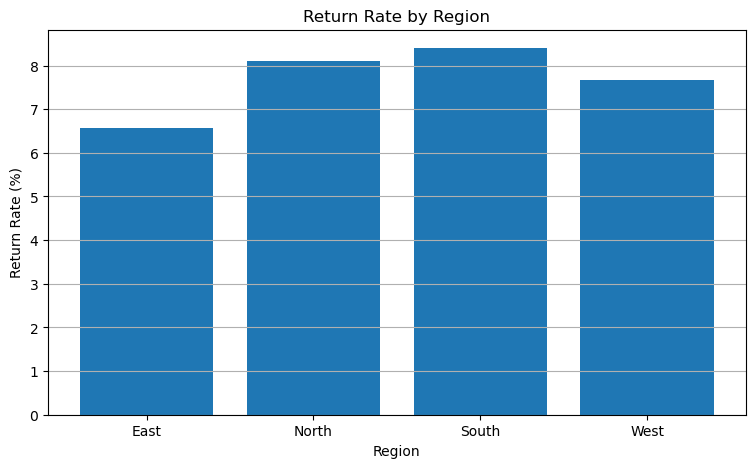

In [39]:
#Return Rate by Region
plt.figure(figsize=(9, 5))

plt.bar(
    region_returns.index,
    region_returns["Return_Rate"]
)

plt.title("Return Rate by Region")
plt.xlabel("Region")
plt.ylabel("Return Rate (%)")

plt.grid(axis="y")

plt.show()

In [41]:
# insights automatically
print("=" * 60)
print("📊 DATAPULSE — DAY 15 AUTOMATED INSIGHTS")
print("=" * 60)

print(
    f"\n1. ORDER OVERVIEW:"
    f"\nDataPulse recorded {total_orders:,} unique orders "
    f"from {total_customers:,} customers."
)


print(
    f"\n3. RETURN-ASSOCIATED REVENUE:"
    f"\nReturned transactions were associated with "
    f"₹{returned_revenue:,.2f} in net sales, representing "
    f"{returned_revenue_pct:.2f}% of total net sales."
)

print(
    f"\n4. PRODUCT RETURN PERFORMANCE:"
    f"\n{highest_return_product} had the highest return rate "
    f"at {highest_return_rate:.2f}%, while "
    f"{lowest_return_product} had the lowest return rate "
    f"at {lowest_return_rate:.2f}%."
)

print(
    f"\n5. REGIONAL RETURN PERFORMANCE:"
    f"\n{highest_return_region} recorded the highest regional "
    f"return rate at {highest_region_rate:.2f}%, while "
    f"{lowest_return_region} recorded the lowest at "
    f"{lowest_region_rate:.2f}%."
)

print(
    f"\n6. DISCOUNTING:"
    f"\nThe overall discount rate was "
    f"{discount_rate_overall:.2f}% of gross sales."
)

print(
    f"\n7. PRODUCT DISCOUNTING:"
    f"\n{highest_discount_product} had the highest average "
    f"discount at {highest_discount:.2f}%."
)

print(
    f"\n8. DISCOUNT VS RETURNS:"
    f"\nReturned orders had an average discount of "
    f"{returned_discount:.2f}%, compared with "
    f"{non_returned_discount:.2f}% for non-returned orders."
)

print(
    f"\nThe difference was "
    f"{discount_difference:.2f} percentage points."
)

print("\n" + "=" * 60)

📊 DATAPULSE — DAY 15 AUTOMATED INSIGHTS

1. ORDER OVERVIEW:
DataPulse recorded 5,000 unique orders from 500 customers.

3. RETURN-ASSOCIATED REVENUE:
Returned transactions were associated with ₹22,104,150.00 in net sales, representing 7.92% of total net sales.

4. PRODUCT RETURN PERFORMANCE:
Webcam had the highest return rate at 9.42%, while Monitor had the lowest return rate at 6.91%.

5. REGIONAL RETURN PERFORMANCE:
South recorded the highest regional return rate at 8.40%, while East recorded the lowest at 6.56%.

6. DISCOUNTING:
The overall discount rate was 7.40% of gross sales.

7. PRODUCT DISCOUNTING:
Headphones had the highest average discount at 0.08%.

8. DISCOUNT VS RETURNS:
Returned orders had an average discount of 0.07%, compared with 0.08% for non-returned orders.

The difference was -0.01 percentage points.



In [43]:
product_risk = (
    product_returns
    .sort_values(
        ["Revenue", "Return_Rate"],
        ascending=[False, False]
    )
)

product_risk

,Orders,Returned_Orders,Revenue,Return_Rate
product,,,,
Laptop,639,49,115261250.0,7.67
Smartphone,649,50,71852000.0,7.70
Tablet,602,45,50097000.0,7.48
Monitor,651,45,26736750.0,6.91
Webcam,616,58,6120625.0,9.42
Headphones,633,48,4321375.0,7.58
Keyboard,612,43,3398100.0,7.03
Mouse,598,46,1307200.0,7.69


In [44]:
product_risk[
    [
        "Revenue",
        "Orders",
        "Returned_Orders",
        "Return_Rate"
    ]
]

,Revenue,Orders,Returned_Orders,Return_Rate
product,,,,
Laptop,115261250.0,639,49,7.67
Smartphone,71852000.0,649,50,7.70
Tablet,50097000.0,602,45,7.48
Monitor,26736750.0,651,45,6.91
Webcam,6120625.0,616,58,9.42
Headphones,4321375.0,633,48,7.58
Keyboard,3398100.0,612,43,7.03
Mouse,1307200.0,598,46,7.69


In [45]:
product_returns.to_csv(
    "../data/processed/product_return_analysis.csv"
)

In [46]:
region_returns.to_csv(
    "../data/processed/region_return_analysis.csv"
)

In [47]:
discount_analysis.to_csv(
    "../data/processed/product_discount_analysis.csv"
)

In [48]:
discount_return.to_csv(
    "../data/processed/discount_return_analysis.csv"
)